# Goldstein branch cuts: neutralize a charged region

How can a path avoid enclosing an unbalanced residue?

We start with numbers that can be checked by hand, draw the algorithm’s decision, then run the public API on data with known truth. All phase values are in radians unless stated otherwise.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd().resolve()
if not (ROOT / 'src' / 'parvaneh').is_dir(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
import parvaneh as pv
plt.rcParams.update({'figure.dpi': 115, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
def W(x): return (np.asarray(x)+np.pi) % (2*np.pi)-np.pi
def table(headers, rows):
    display(Markdown('| '+' | '.join(headers)+' |\n|'+
        '|'.join(['---']*len(headers))+'|\n'+
        '\n'.join('| '+' | '.join(map(str,r))+' |' for r in rows)))
def images(arrays, titles, cmap='viridis'):
    fig,axes=plt.subplots(1,len(arrays),figsize=(4*len(arrays),3.4),constrained_layout=True)
    for ax,a,title in zip(np.atleast_1d(axes),arrays,titles):
        im=ax.imshow(a,cmap=cmap); ax.set(title=title,xlabel='column',ylabel='row')
        fig.colorbar(im,ax=ax,shrink=.75)
    plt.show()
def align(u,t): return u-np.mean(u-t)
def scene():
    y,x=np.mgrid[0:18,0:22]
    truth=.38*x+.22*y+1.4*np.exp(-((x-12)**2+(y-8)**2)/25)
    patch=(x>=8)&(x<=14)&(y>=5)&(y<=12)
    rng=np.random.default_rng(21)
    phase=W(truth+rng.normal(size=truth.shape)*np.where(patch,1.35,.06))
    confidence=np.where(patch,.2,1.)
    return truth,phase,confidence
def report(u,t,w):
    assert u.shape==t.shape and np.isfinite(u).all()
    table(['Quantity','Measured value'],[
        ['Aligned RMSE (rad)',f'{pv.rmse_aligned(u,t):.6f}'],
        ['Raw max wrapped difference from input (rad)',f'{np.max(np.abs(W(u-w))):.6f}']])
    images([align(u,t),align(u,t)-t],['Aligned reconstruction (rad)','Error against truth (rad)'])

## 1 · Work through the model

For clockwise steps around a cell, $r=(g_{top}+g_{right}-g_{bottom}-g_{left})/(2\pi)$.
The charge is an integer because these steps come from wrapped pixel values.
A region containing charges $+1,-1$ is balanced: its total is zero. One containing
$+1,+1,-1$ still has charge $+1$ and cannot be treated as neutral.

Expand a search box around a charged cell. Gather other charges until the group is balanced, connecting them by cuts; if needed connect to the boundary. The cut map records forbidden traversal pixels. This is the method in which the integration path must not cross the cut. During path following, the cut pixels are temporarily excluded, so a path cannot enter or cross the chain of cut pixels. This prevents two routes from enclosing a non-zero residue and disagreeing by a whole turn. Classical diagrams draw a branch cut as a curve joining residue cells; this implementation rasterizes that curve as a boolean pixel mask. It fills those pixels later from an already unwrapped neighbour.

After constructing cuts, integrate only through allowed paths. Then fill cut
pixels from adjacent integrated pixels where possible. Cut placement is a
heuristic geometric decision, not the same optimization as minimum-cost flow.

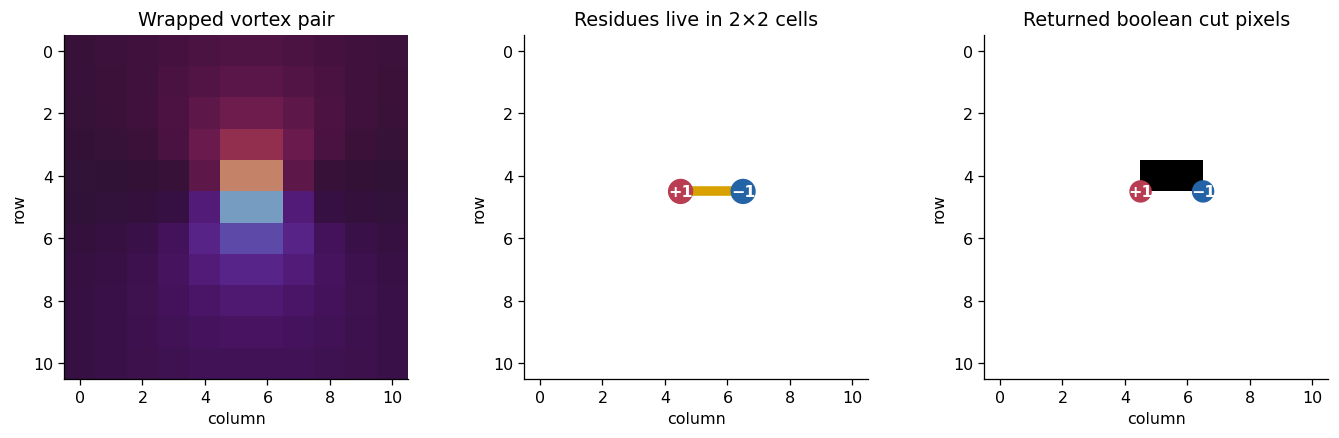

Positive residue [row, col]: [[4, 4]]
Negative residue [row, col]: [[4, 6]]
Cut pixels [row, col]: [[4, 5], [4, 6]]


In [2]:
rows=cols=11
y,x=np.mgrid[:rows,:cols]
vortex=(4.5,4.5); antivortex=(6.5,4.5)
pair_phase=W(np.angle((x-vortex[0])+1j*(y-vortex[1]))
             -np.angle((x-antivortex[0])+1j*(y-antivortex[1])))
charge=pv.phase_residues(pair_phase)
_,cut_pixels=pv.goldstein_unwrap(pair_phase,return_cuts=True,max_cut_length=20)
positive=np.argwhere(charge==1); negative=np.argwhere(charge==-1)
assert positive.tolist()==[[4,4]] and negative.tolist()==[[4,6]]
assert np.argwhere(cut_pixels).tolist()==[[4,5],[4,6]]
fig,axes=plt.subplots(1,3,figsize=(12,3.7),constrained_layout=True)
axes[0].imshow(pair_phase,cmap='twilight',vmin=-np.pi,vmax=np.pi)
axes[0].set_title('Wrapped vortex pair')
axes[1].imshow(np.zeros_like(pair_phase),cmap='Greys',vmin=0,vmax=1)
axes[1].plot([4.5,6.5],[4.5,4.5],color='#d8a100',lw=6,
             label='conceptual branch cut')
axes[1].scatter([4.5,6.5],[4.5,4.5],c=['#b83d52','#2463a6'],s=220,zorder=3)
axes[1].text(4.5,4.5,'+1',color='white',ha='center',va='center',weight='bold')
axes[1].text(6.5,4.5,'−1',color='white',ha='center',va='center',weight='bold')
axes[1].set_title('Residues live in 2×2 cells')
axes[2].imshow(cut_pixels,cmap='Greys',vmin=0,vmax=1)
axes[2].scatter([4.5,6.5],[4.5,4.5],c=['#b83d52','#2463a6'],s=170,zorder=3)
axes[2].text(4.5,4.5,'+1',color='white',ha='center',va='center',weight='bold')
axes[2].text(6.5,4.5,'−1',color='white',ha='center',va='center',weight='bold')
axes[2].set_title('Returned boolean cut pixels')
for ax in axes:
    ax.set(xlabel='column',ylabel='row',xticks=range(0,11,2),yticks=range(0,11,2))
plt.show()
print('Positive residue [row, col]:',positive.tolist())
print('Negative residue [row, col]:',negative.tolist())
print('Cut pixels [row, col]:',np.argwhere(cut_pixels).tolist())

## 2 · Read the calculation

The middle panel shows the mathematical idea: the positive and negative residue
cells are paired by one branch cut. The right panel shows this implementation's
representation of that same connection. Black entries are actual pixels skipped
during the first integration pass, not edges between pixels. The coloured
markers remain at cell centres, which is why they are offset by half a sample
from the cut-pixel coordinates printed below. The next example shows the same
returned mask on the larger synthetic scene.

## 3 · Run the implementation

The seed and input sizes below are fixed. A low objective or a converged solver means the chosen mathematical problem was solved; it does not prove the physical phase was recovered.

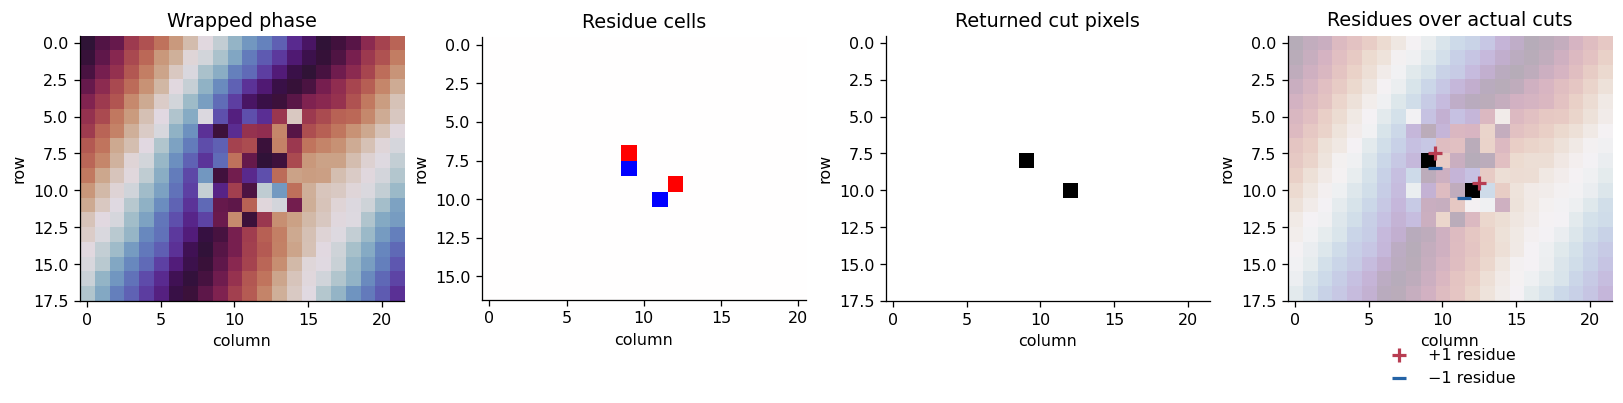

| Evidence | Value |
|---|---|
| Positive residue cells | [[7, 9], [9, 12]] |
| Negative residue cells | [[8, 9], [10, 11]] |
| Net residue charge | 0 |
| Cut pixels | [[8, 9], [10, 12]] |

| Quantity | Measured value |
|---|---|
| Aligned RMSE (rad) | 0.455811 |
| Raw max wrapped difference from input (rad) | 3.141593 |

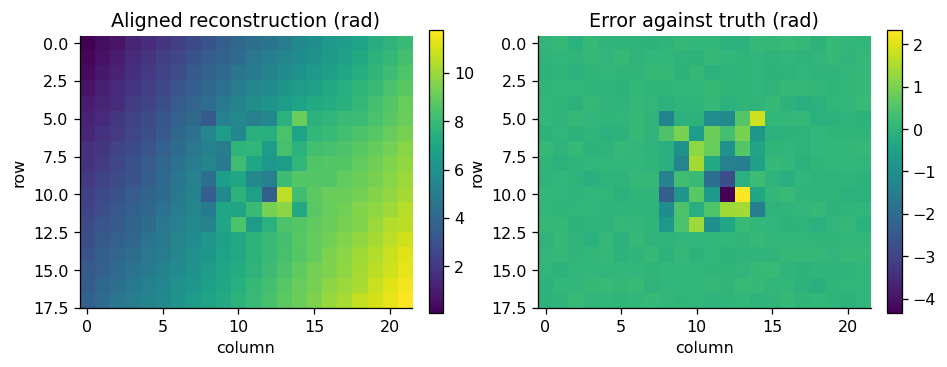

In [3]:
truth,phase,confidence=scene()
u,cuts=pv.goldstein_unwrap(phase,return_cuts=True)
residues=pv.phase_residues(phase)
positive=np.argwhere(residues==1); negative=np.argwhere(residues==-1)
fig,axes=plt.subplots(1,4,figsize=(14,3.4),constrained_layout=True)
axes[0].imshow(phase,cmap='twilight',vmin=-np.pi,vmax=np.pi)
axes[0].set_title('Wrapped phase')
axes[1].imshow(residues,cmap='bwr',vmin=-1,vmax=1)
axes[1].set_title('Residue cells')
axes[2].imshow(cuts,cmap='Greys',vmin=0,vmax=1)
axes[2].set_title('Returned cut pixels')
axes[3].imshow(phase,cmap='twilight',vmin=-np.pi,vmax=np.pi,alpha=.35)
axes[3].imshow(np.ma.masked_where(~cuts,cuts),cmap='Greys',vmin=0,vmax=1)
axes[3].scatter(positive[:,1]+.5,positive[:,0]+.5,c='#b83d52',s=70,
                marker='+',linewidths=2,label='+1 residue')
axes[3].scatter(negative[:,1]+.5,negative[:,0]+.5,c='#2463a6',s=70,
                marker='_',linewidths=2,label='−1 residue')
axes[3].set_title('Residues over actual cuts')
axes[3].legend(loc='upper center',bbox_to_anchor=(.5,-.12),frameon=False)
for ax in axes: ax.set(xlabel='column',ylabel='row')
plt.show()
table(['Evidence','Value'],[
    ['Positive residue cells',positive.tolist()],
    ['Negative residue cells',negative.tolist()],
    ['Net residue charge',int(residues.sum())],
    ['Cut pixels',np.argwhere(cuts).tolist()]])
report(u,truth,phase)

## 4 · Change one choice and measure its effect

This controlled experiment changes a solver setting, data condition, or reference calculation. Compare the measured values before drawing a conclusion.

In [4]:
clean=.3*np.add.outer(np.arange(8),np.arange(9)); wrapped=W(clean)
rows=[]
for name,method in [('Goldstein',pv.goldstein_unwrap),('Mask cut',pv.mask_cut_unwrap)]:
    v,cut=method(wrapped,return_cuts=True)
    rows.append([name,int(cut.sum()),f'{pv.rmse_aligned(v,clean):.2e}',
                 f'{np.mean(v-clean):.4f}'])
table(['Method','Cuts on clean ramp','Aligned RMSE','Mean offset (rad)'],rows)

| Method | Cuts on clean ramp | Aligned RMSE | Mean offset (rad) |
|---|---|---|---|
| Goldstein | 0 | 4.37e-07 | 3.1416 |
| Mask cut | 0 | 4.37e-07 | 3.1416 |

## 5 · Interpretation and limits

These are 2-D algorithms. Their float32 cycle representation shifts the phase
origin by approximately $\pi$ on a clean ramp; the printed mean offset reveals
that convention. Cut filling can leave zero values when no adjacent integrated
pixel exists, and excluded mask pixels are also zero. Inspect the cut map and
validity mask; a finite number alone does not guarantee a recovered measurement.
Neither short cuts nor few cut pixels guarantees lower error against truth.

## Continue exploring

Rerun with another seed or a larger phase step. Predict which assumption fails first, then inspect the result and report. The method’s output convention and masks matter as much as its RMSE.

Implementation: [`goldstein.py`](../src/parvaneh/goldstein.py). See the [API reference](../docs/api.md), [notebook index](../docs/notebooks.md), [mathematical derivations](../docs/mathematics.md), and [bibliography](../docs/references.md) for further reading. These examples describe the current implementation, including its limitations; they are not claims of numerical identity with external software.